In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_pickle('train_dataset_normalized.pkl')

In [ ]:
# Разделение признаков на числовые и категориальные
numerical_features = ['Число очагов', 'Объем очагов', 'Число РХ процедур',
                        'Индекс Карновского', 'Возраст', 'Время метастазирования',
                        'Время реагирования']
categorical_features = ['ОВГМ', 'Операция', 'КРР', 'Меланома', 'НМРЛ',
                        'РМЖ', 'РП', 'Таргетная терапия', 'Химиотерапия', 'Без лечения', 'Мужчина']
target = 'Прогрессия'

In [ ]:
df.head()

,Прогрессия,Число очагов,Объем очагов,Число РХ процедур,Индекс Карновского,ОВГМ,Операция,Возраст,Время метастазирования,Время реагирования,КРР,Меланома,НМРЛ,РМЖ,РП,Таргетная терапия,Химиотерапия,Без лечения,Мужчина
0,1,0.095238,0.008543,0.0,0.666667,0,0,0.490909,0.076249,0.165963,0,1,0,0,0,0,1,0,1
1,1,0.095238,0.101619,0.0,0.666667,0,0,0.690909,0.034228,-0.004219,0,0,0,0,1,0,0,0,1
2,0,0.476190,0.178732,0.0,0.666667,0,0,0.454545,0.203423,0.018284,1,0,0,0,0,0,1,0,0
3,1,0.285714,0.062950,0.2,0.666667,0,0,0.472727,0.068179,0.030942,0,0,0,1,0,1,0,0,0
4,1,0.476190,0.127023,0.8,0.666667,0,0,0.472727,0.012801,0.014065,0,0,0,0,1,1,0,0,0


### 1. **Визуальный анализ распредлений**(графики плотности распредления для числовых признаков и диаграммы для категориальных). Разделяем признаки на две группы(с прогрессией/без прогрессии)

In [ ]:
from scipy import stats

def plot_density_by_target(df, feature, target='Прогрессия',
                           figsize=(10, 6)):
    fig, ax = plt.subplots(figsize=figsize)

    # Разделение данных по целевой переменной
    no_progression = df[df[target] == 0][feature].dropna()
    with_progression = df[df[target] == 1][feature].dropna()

    # Построение плотностей только в диапазоне данных каждой группы
    x_no = np.linspace(no_progression.min(), no_progression.max(), 1000)
    kde_no = stats.gaussian_kde(no_progression)
    ax.plot(x_no, kde_no(x_no), label='Без прогрессии',
            linewidth=2.5, alpha=0.7)

    x_with = np.linspace(with_progression.min(), with_progression.max(), 1000)
    kde_with = stats.gaussian_kde(with_progression)
    ax.plot(x_with, kde_with(x_with), label='С прогрессией',
            linewidth=2.5, alpha=0.7)

    # Добавление медиан
    ax.axvline(no_progression.median(), color='C0', linestyle='--',
               alpha=0.5, label=f'Медиана (без): {no_progression.median():.2f}')
    ax.axvline(with_progression.median(), color='C1', linestyle='--',
               alpha=0.5, label=f'Медиана (с): {with_progression.median():.2f}')

    ax.set_xlabel(feature)
    ax.set_ylabel('Плотность')
    ax.set_title(f'Распределение признака "{feature}"')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

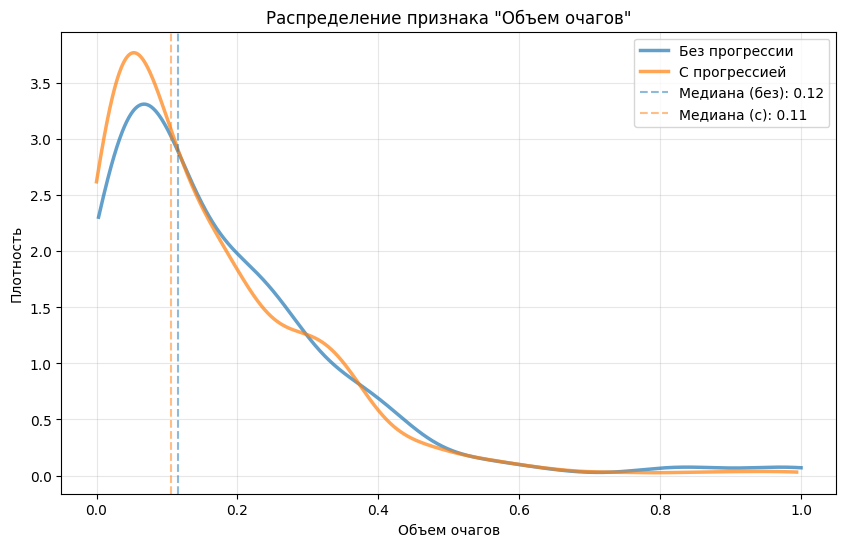

In [ ]:
plot_density_by_target(df, 'Объем очагов', target)

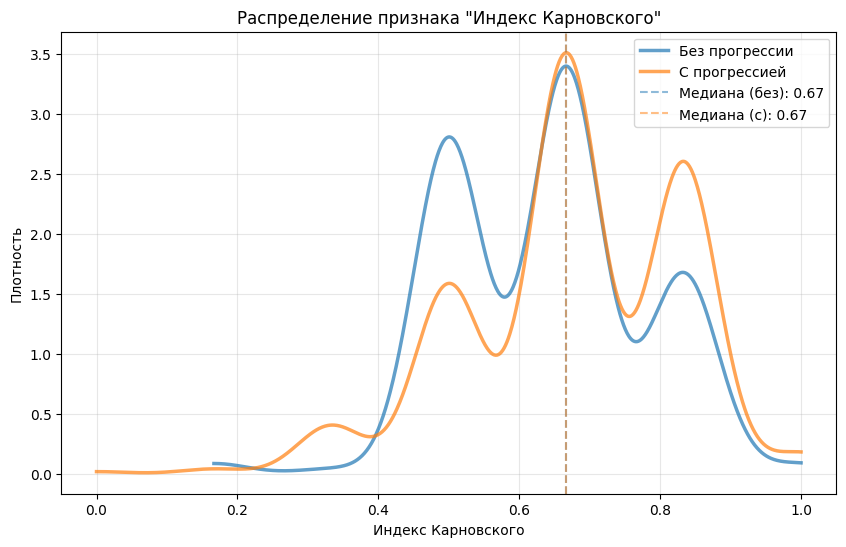

In [ ]:
plot_density_by_target(df, 'Индекс Карновского', target)

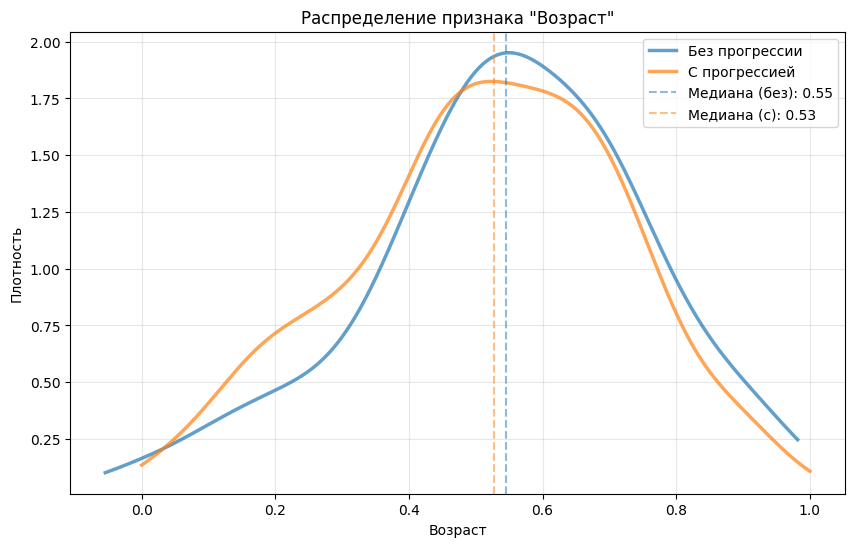

In [ ]:
plot_density_by_target(df, 'Возраст', target)

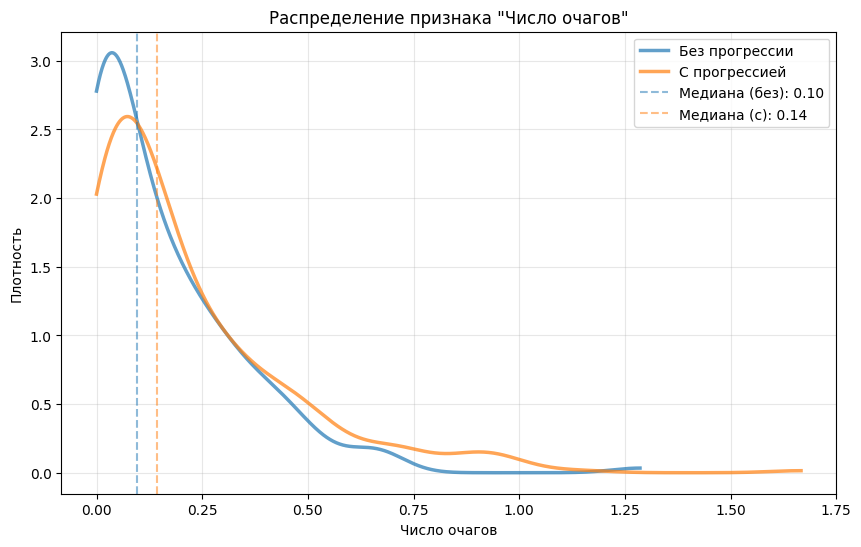

In [ ]:
plot_density_by_target(df, 'Число очагов', target)

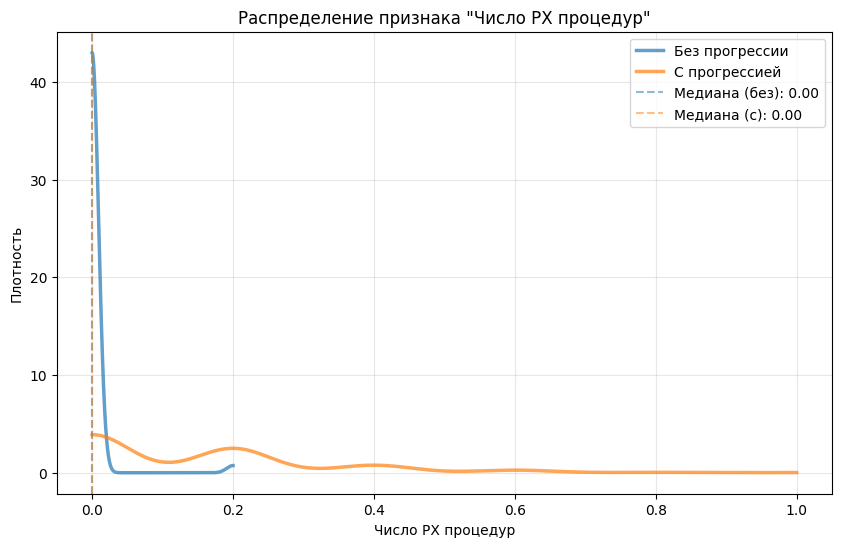

In [ ]:
plot_density_by_target(df, 'Число РХ процедур', target)

<Figure size 1000x600 with 0 Axes>

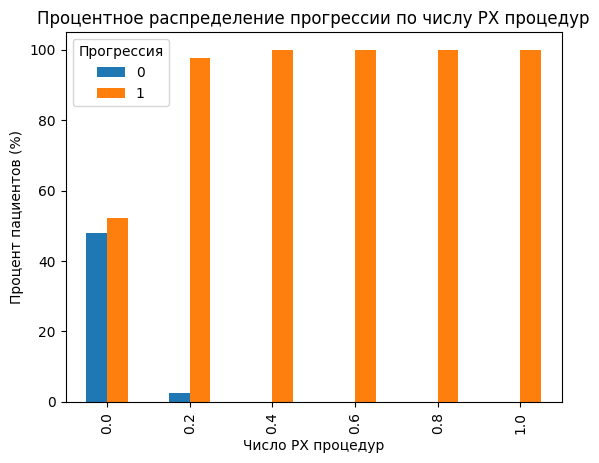

In [ ]:
#Процентное распределение для наглядности
plt.figure(figsize=(10, 6))
progression_pct = pd.crosstab(df['Число РХ процедур'], df['Прогрессия'], normalize='index') * 100
progression_pct.plot(kind='bar')
plt.title('Процентное распределение прогрессии по числу РХ процедур')
plt.ylabel('Процент пациентов (%)')
plt.show()

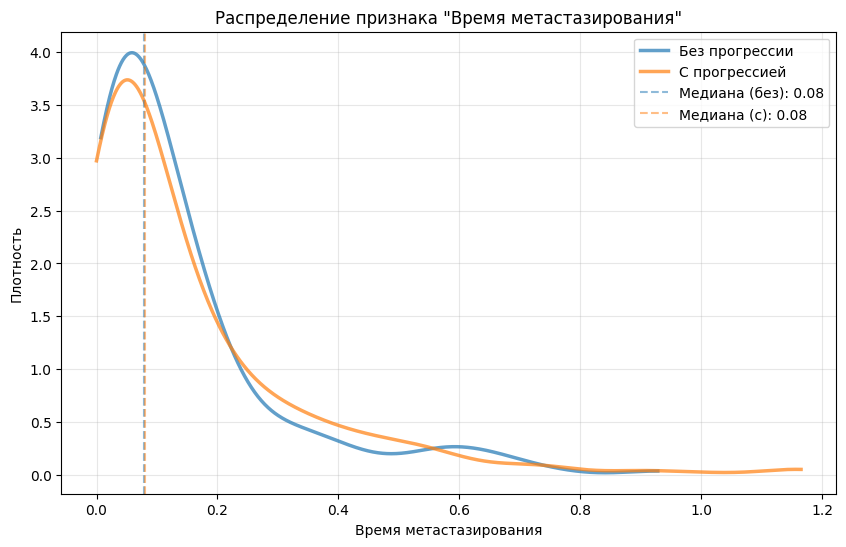

In [ ]:
plot_density_by_target(df, 'Время метастазирования', target)

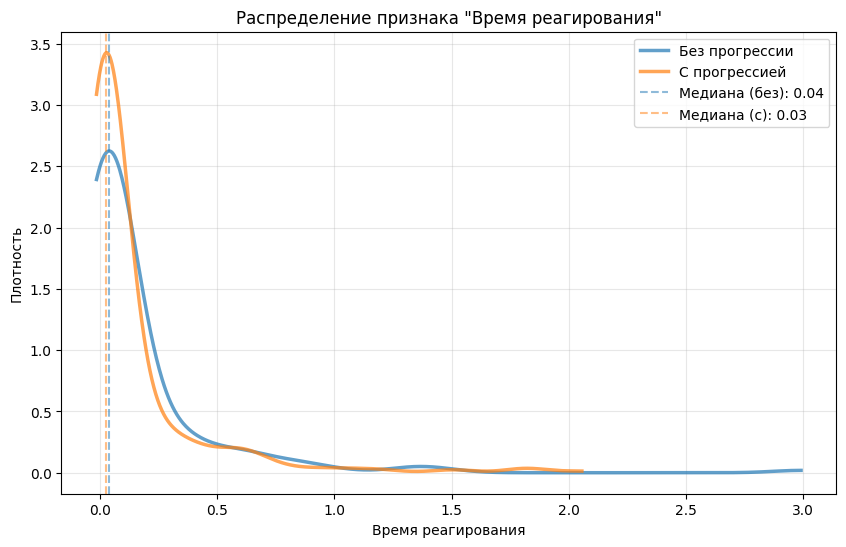

In [ ]:
plot_density_by_target(df, 'Время реагирования', target)

In [ ]:
def plot_categorical_features(df, categorical_features, target):
    n_features = len(categorical_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, feature in enumerate(categorical_features):
        ax = axes[i]

        pivot_data = pd.crosstab(df[feature], df[target], normalize='index') * 100

        bars = pivot_data.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black')

        ax.set_title(f'Распределение признака "{feature}"\nпо группам прогрессии', fontsize=14, fontweight='bold')
        ax.set_xlabel(feature, fontsize=12)
        ax.set_ylabel('Процент пациентов (%)', fontsize=12)
        ax.legend(['Без прогрессии', 'С прогрессией'], fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)

        for container in bars.containers:
            ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

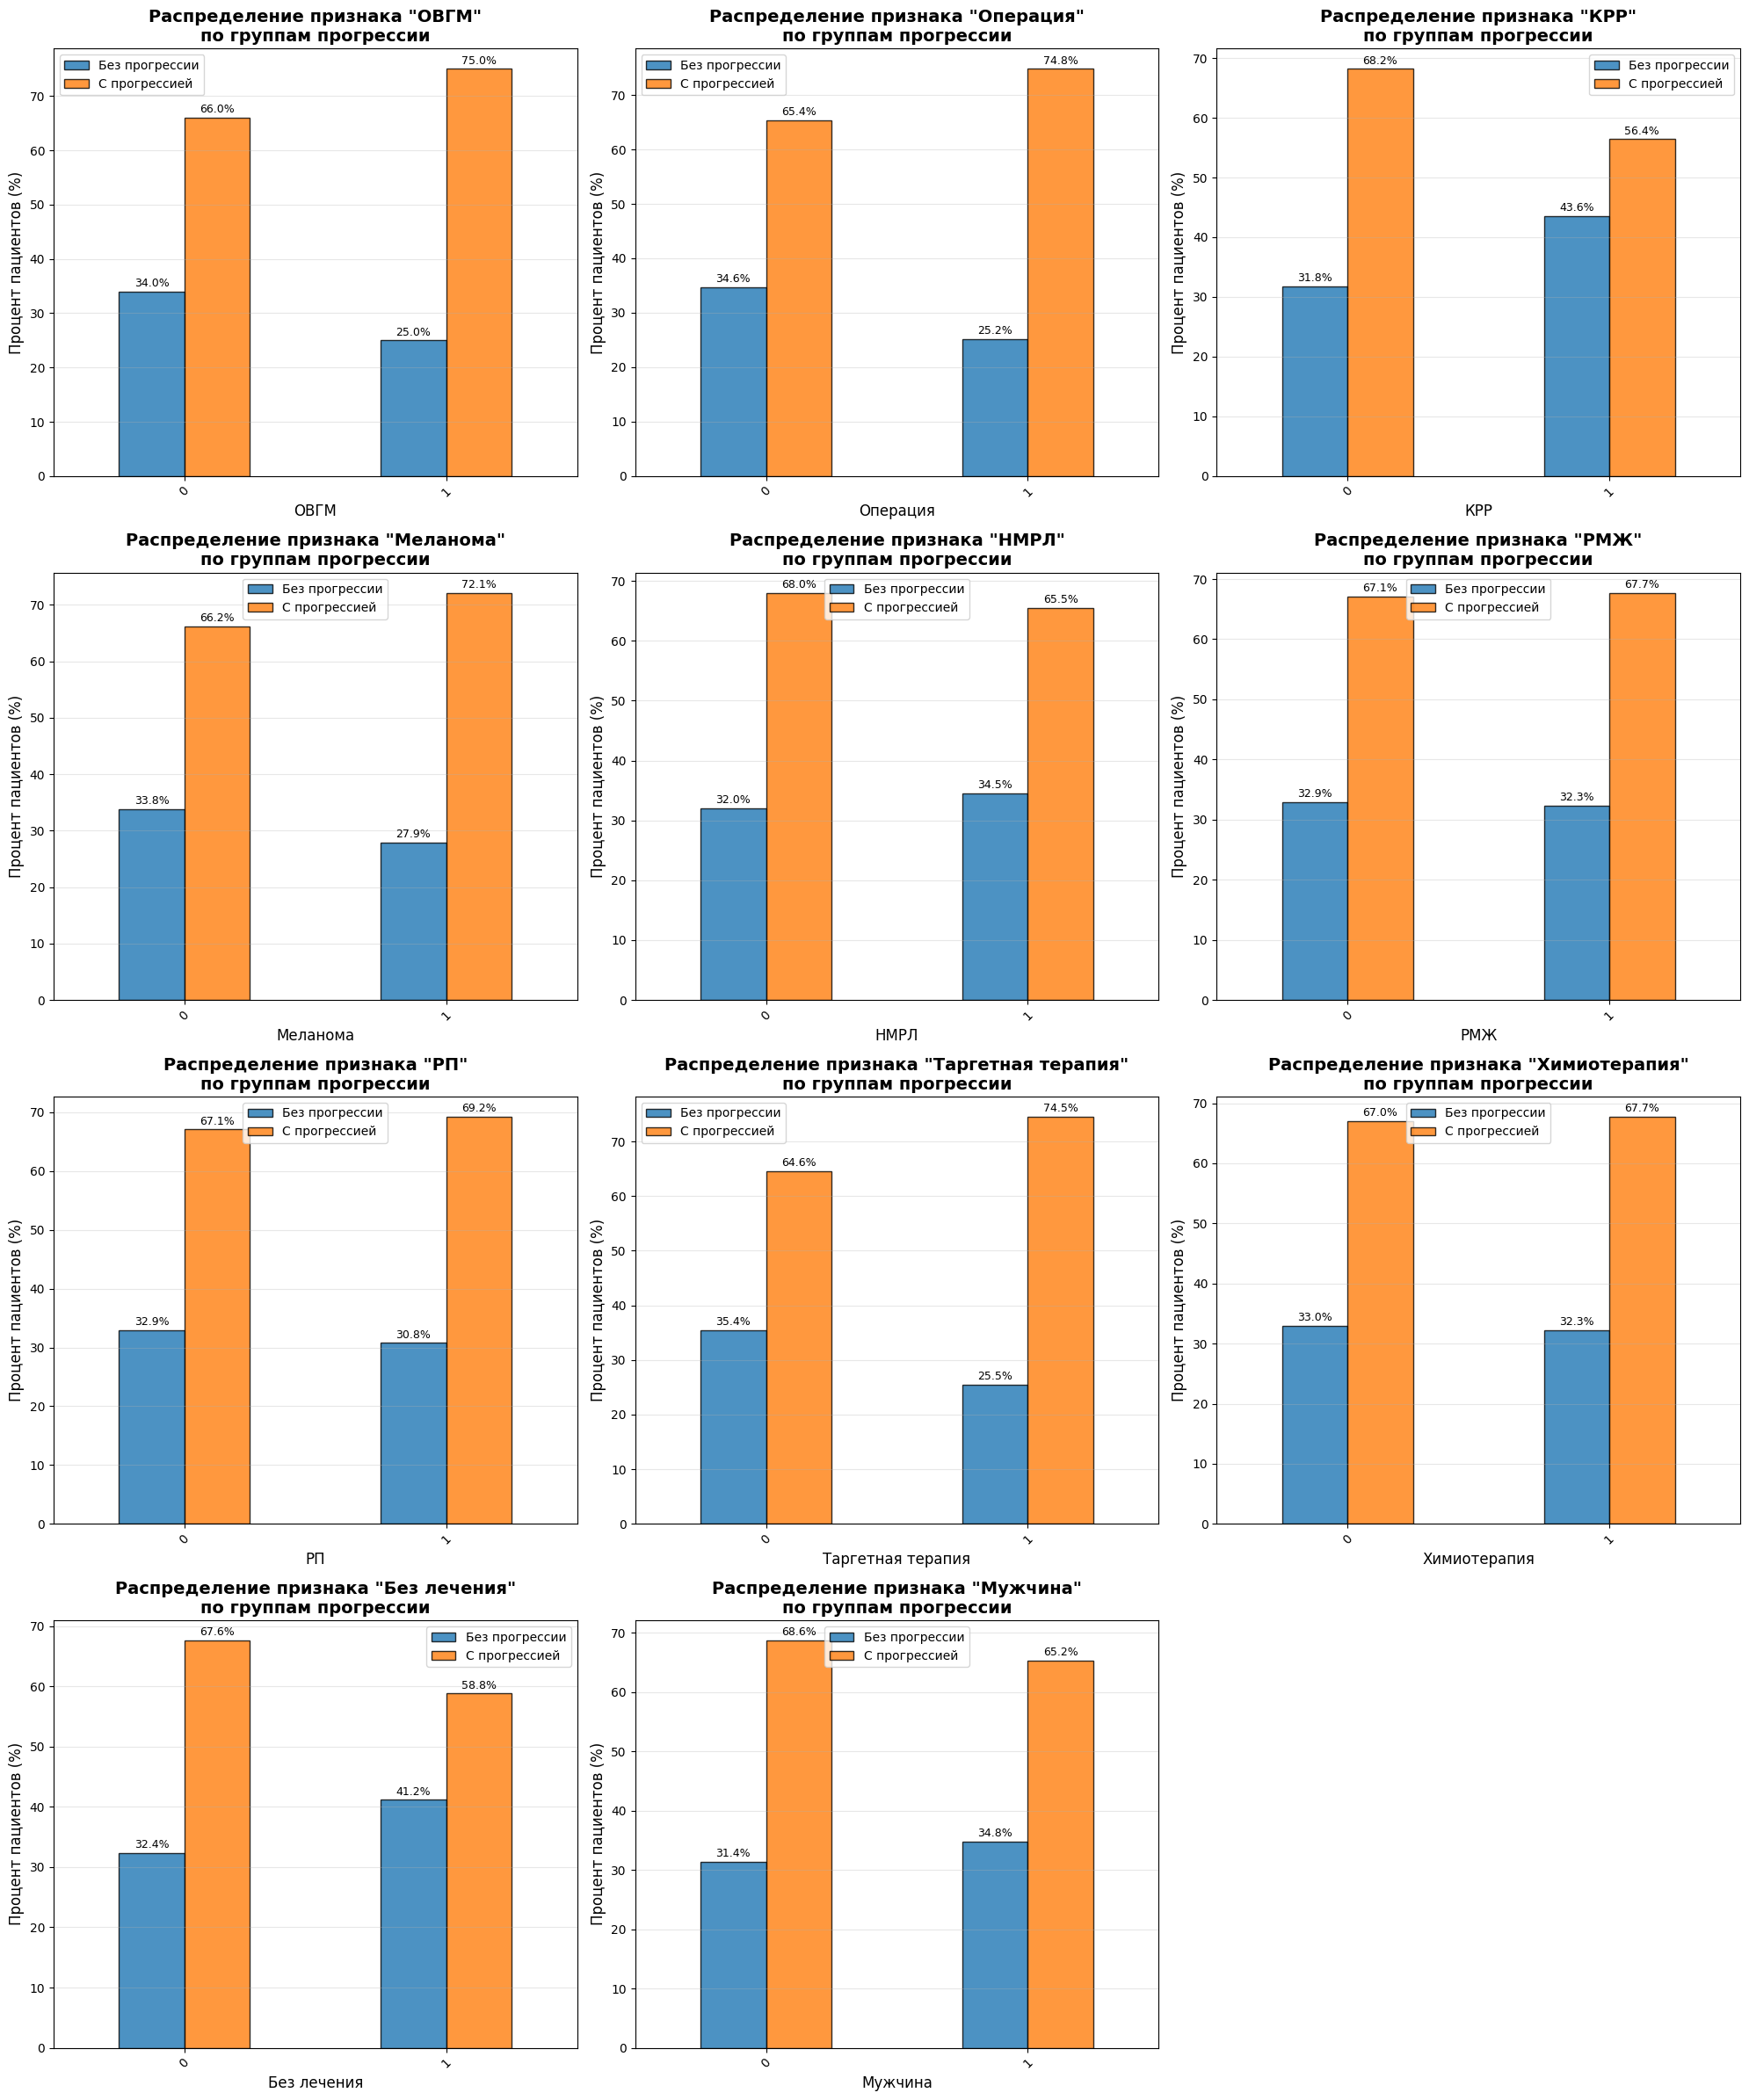

In [ ]:
plot_categorical_features(df, categorical_features, target)

# Анализ визуальных различий. Выводы:
1. При визуальном анализе графика с распределнием признака "Число РХ процедур" прослеживается увеличение числа пациентов с прогрессией при росте числа РХ, при 0 РХ процедур количество пациентов с прогрессией и без примерно одинаково.
2. Интересен график распределения признака "Индекс Карновского". Медианы совпадают, однако в остальном с увеличением индекса число пациентов без прогрессии уменьшается, а с прогрессией увеличивается.
3. Распределения остальных числовых признаков практически идентичны и требуют более глубокого анализа.
4. Графики распределения категариальных признаков показали:


*   Процент пациентов с прогрессией в 3 раза больше процента пациентов без прогресси среди тех, кто имел ОВГМ => ОВГМ значимый предиктор прогрессии.
*   Похожая ситуация наблядается среди пациентов, у которых была меланома, а также которые проходили таргетную терапию.



# 2. **Количественный анализ числовых признаков**(d*, относительное различие в процентах через медианы, процент перекрытия распределний)

## Коэффициент d Коэна

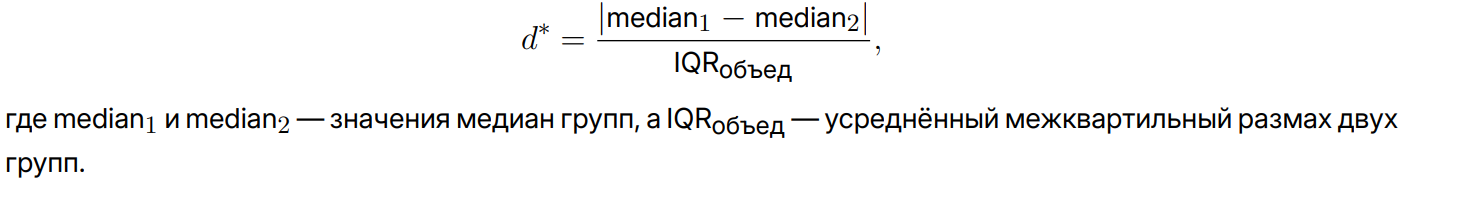

In [ ]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    median1 = np.median(group1)
    median2 = np.median(group2)

    # Межквартильные размахи (IQR)
    q1_1, q3_1 = np.percentile(group1, [25, 75])
    q1_2, q3_2 = np.percentile(group2, [25, 75])

    iqr1 = q3_1 - q1_1
    iqr2 = q3_2 - q1_2

    # Усредненный межквартильный размах
    iqr_pooled = (iqr1 + iqr2) / 2

    # d для медиан
    d_star = abs(median1 - median2) / iqr_pooled

    return d_star



def relative_difference(group1, group2, base_group=1):
    mean1, mean2 = group1.mean(), group2.mean()

    if base_group == 1:
        base_mean = mean1
    else:
        base_mean = mean2

    if base_mean == 0:
        return np.nan

    return abs(mean1 - mean2) / base_mean * 100


def parametric_overlap(group1, group2):
    mu1, std1 = group1.mean(), group1.std()
    mu2, std2 = group2.mean(), group2.std()

    # Создаём сетку значений
    min_val = min(mu1 - 4*std1, mu2 - 4*std2)
    max_val = max(mu1 + 4*std1, mu2 + 4*std2)
    x = np.linspace(min_val, max_val, 10000)

    # Вычисляем плотности
    pdf1 = norm.pdf(x, mu1, std1)
    pdf2 = norm.pdf(x, mu2, std2)

    # Площадь перекрытия = интеграл от минимума двух плотностей
    overlap = np.trapezoid(np.minimum(pdf1, pdf2), x)

    return overlap * 100


def visualize_overlap(group1, group2, feature_name):
    mu1, std1 = group1.mean(), group1.std()
    mu2, std2 = group2.mean(), group2.std()

    # Создаём сетку значений
    min_val = min(mu1 - 4*std1, mu2 - 4*std2)
    max_val = max(mu1 + 4*std1, mu2 + 4*std2)
    x = np.linspace(min_val, max_val, 1000)

    # Вычисляем плотности
    pdf1 = norm.pdf(x, mu1, std1)
    pdf2 = norm.pdf(x, mu2, std2)

    # Находим минимум для перекрытия
    overlap_area = np.minimum(pdf1, pdf2)
    overlap = np.trapezoid(overlap_area, x)

    # Построение графика
    fig, ax = plt.subplots(figsize=(12, 7))

    # Рисуем распределения
    ax.plot(x, pdf1, 'b-', linewidth=2.5, label='Без прогрессии', alpha=0.7)
    ax.plot(x, pdf2, 'orange', linewidth=2.5, label='С прогрессией', alpha=0.7)

    # Закрашиваем перекрытие
    ax.fill_between(x, 0, overlap_area, alpha=0.5, color='purple',
                    label=f'Перекрытие ({overlap*100:.2f} %)')

    # Добавляем вертикальные линии для средних
    ax.axvline(mu1, color='blue', linestyle='--', alpha=0.5,
              label=f'μ₁ = {mu1:.3f}')
    ax.axvline(mu2, color='orange', linestyle='--', alpha=0.5,
              label=f'μ₂ = {mu2:.3f}')

    ax.set_xlabel(feature_name)
    ax.set_ylabel('Плотность')
    ax.set_title(f'Перекрытие нормальных распределений: {feature_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def analyze_numerical_features(df, numerical_features, target='Прогрессия'):
    results = []

    for feature in numerical_features:
        # Разделение по целевой переменной
        no_prog = df[df[target] == 0][feature].dropna()
        with_prog = df[df[target] == 1][feature].dropna()

        # Вычисление метрик
        mean_no_prog = no_prog.mean()
        mean_with_prog = with_prog.mean()

        d = cohens_d(no_prog, with_prog)
        rel_diff = relative_difference(no_prog, with_prog, base_group=1)
        overlap = parametric_overlap(no_prog, with_prog)

        results.append({
            'Признак': feature,
            'μ (без прогр.)': f"{mean_no_prog:.2f}",
            'μ (с прогр.)': f"{mean_with_prog:.2f}",
            'd Коэна': f"{d:.2f}",
            'Различие (%)': f"{rel_diff:.2f}",
            'Перекрытие (%)': f"{overlap:.2f}"
        })

    return pd.DataFrame(results)

In [ ]:
results_table = analyze_numerical_features(df, numerical_features, target)
results_table

,Признак,μ (без прогр.),μ (с прогр.),d Коэна,Различие (%),Перекрытие (%)
0,Число очагов,0.16,0.22,0.20,37.14,84.63
1,Объем очагов,0.17,0.16,0.06,9.15,93.33
2,Число РХ процедур,0.00,0.14,0.00,3958.63,21.87
3,Индекс Карновского,0.64,0.67,0.00,5.28,89.83
4,Возраст,0.54,0.52,0.07,5.46,94.22
5,Время метастазирования,0.14,0.15,0.01,11.47,91.48
6,Время реагирования,0.15,0.13,0.11,12.27,93.29


# Выводы по количественному анализу:


*   пациенты с прогрессией во много раз чаще получали РХ процедуры, наличие РХ - важные предиктор прогрессии
* коэффициент Коэна(найденный нашим способом) не информативен для данных с медианным значением 0
*   метрики показали, что индекс Карновского не является важным предиктором прогрессии, перекрытие - 89%
* все остальные признаки имеют минимальные различия



# 3. Анализ категориальные признаки через таблицы сопряженности

In [ ]:
total_V = {}

def analyze_2x2_table(df, feature, target='Прогрессия'):
    # Построение таблицы сопряжённости
    contingency = pd.crosstab(df[feature], df[target], margins=True)

    print("Таблица сопряжённости:")
    display(contingency)

    # Извлечение значений
    # feature=0, target=0
    a = contingency.iloc[0, 0]
    # feature=0, target=1
    b = contingency.iloc[0, 1]
    # feature=1, target=0
    c = contingency.iloc[1, 0]
    # feature=1, target=1
    d = contingency.iloc[1, 1]

    # Вычисление рисков
    R1 = b / (a + b)
    R2 = d / (c + d)

    # Вычисление шансов
    O1 = b / a if a > 0 else np.inf
    O2 = d / c if c > 0 else np.inf

    # Меры сравнения
    RD = R1 - R2
    RR = R1 / R2 if R2 > 0 else np.inf
    OR = O1 / O2 if O2 > 0 and O2 != np.inf and O1 != np.inf else np.inf

    print(f"Риски:")
    print(f"  R({feature}=0) = {b}/{a+b} = {R1:.3f} ({R1*100:.1f}%)")
    print(f"  R({feature}=1) = {d}/{c+d} = {R2:.3f} ({R2*100:.1f}%)")
    print()

    print(f"Шансы:")
    print(f"  O({feature}=0) = {b}/{a} = {O1:.2f}")
    print(f"  O({feature}=1) = {d}/{c} = {O2:.2f}")
    print()

    print(f"Меры сравнения:")
    print(f"  RD (разница рисков) = {RD:.3f}")
    print(f"  RR (относительный риск) = {RR:.2f}")
    print(f"  OR (отношение шансов) = {OR:.2f}")
    print()

    return {
        'feature': feature,
        'R1': R1, 'R2': R2,
        'O1': O1, 'O2': O2,
        'RD': RD, 'RR': RR, 'OR': OR
    }


def analyze_contingency_table(df, feature, target='Прогрессия'):
    # Построение таблицы сопряжённости
    observed = pd.crosstab(df[feature], df[target], margins=True)

    print("Наблюдаемые частоты:")
    display(observed)

    # Вычисление ожидаемых частот
    n = observed.iloc[-1, -1]
    expected = pd.DataFrame(
        index=observed.index[:-1],
        columns=observed.columns[:-1]
    )

    for i in observed.index[:-1]:
        for j in observed.columns[:-1]:
            row_sum = observed.loc[i, 'All']
            col_sum = observed.loc['All', j]
            expected.loc[i, j] = (row_sum * col_sum) / n

    print("Ожидаемые частоты:")
    display(expected.round(2))

    # Вычисление χ²
    chi2 = 0
    for i in observed.index[:-1]:
        for j in observed.columns[:-1]:
            O_ij = observed.loc[i, j]
            E_ij = expected.loc[i, j]
            chi2 += (O_ij - E_ij)**2 / E_ij

    # Вычисление V Крамера
    nr = len(observed.index) - 1
    nc = len(observed.columns) - 1
    V = np.sqrt(chi2 / (n * min(nr - 1, nc - 1)))

    total_V[feature] = V

    print(f"Статистика χ² = {chi2:.2f}")
    print(f"Коэффициент V Крамера = {V:.3f}")

    # Интерпретация V Крамера
    if V < 0.1:
        strength = "Очень слабая или отсутствует"
    elif V < 0.2:
        strength = "Слабая"
    elif V < 0.4:
        strength = "Умеренная"
    elif V < 0.6:
        strength = "Относительно сильная"
    else:
        strength = "Сильная"

    print(f"Сила связи: {strength}")

    return {
        'feature': feature,
        'chi2': chi2,
        'V_cramer': V,
        'strength': strength
    }

Анализируем бинарные признаки

In [ ]:
print(df.columns)

Index(['Прогрессия', 'Число очагов', 'Объем очагов', 'Число РХ процедур',
       'Индекс Карновского', 'ОВГМ', 'Операция', 'Возраст',
       'Время метастазирования', 'Время реагирования', 'КРР', 'Меланома',
       'НМРЛ', 'РМЖ', 'РП', 'Таргетная терапия', 'Химиотерапия', 'Без лечения',
       'Мужчина'],
      dtype='object')


In [ ]:
print('Анализ таблицы сопряженности признака: Прогрессия')
analyze_2x2_table(df, 'Прогрессия', target)

Анализ таблицы сопряженности признака: Прогрессия
Таблица сопряжённости:


Прогрессия,0,1,All
Прогрессия,,,
0,179,0,179
1,0,369,369
All,179,369,548


Риски:
  R(Прогрессия=0) = 0/179 = 0.000 (0.0%)
  R(Прогрессия=1) = 369/369 = 1.000 (100.0%)

Шансы:
  O(Прогрессия=0) = 0/179 = 0.00
  O(Прогрессия=1) = 369/0 = inf

Меры сравнения:
  RD (разница рисков) = -1.000
  RR (относительный риск) = 0.00
  OR (отношение шансов) = inf



{'feature': 'Прогрессия',
 'R1': np.float64(0.0),
 'R2': np.float64(1.0),
 'O1': np.float64(0.0),
 'O2': inf,
 'RD': np.float64(-1.0),
 'RR': np.float64(0.0),
 'OR': inf}

In [ ]:
print('Анализ таблицы сопряженности признака: ОВГМ')
analyze_2x2_table(df, 'ОВГМ', target)

Анализ таблицы сопряженности признака: ОВГМ
Таблица сопряжённости:


Прогрессия,0,1,All
ОВГМ,,,
0,159,309,468
1,20,60,80
All,179,369,548


Риски:
  R(ОВГМ=0) = 309/468 = 0.660 (66.0%)
  R(ОВГМ=1) = 60/80 = 0.750 (75.0%)

Шансы:
  O(ОВГМ=0) = 309/159 = 1.94
  O(ОВГМ=1) = 60/20 = 3.00

Меры сравнения:
  RD (разница рисков) = -0.090
  RR (относительный риск) = 0.88
  OR (отношение шансов) = 0.65



{'feature': 'ОВГМ',
 'R1': np.float64(0.6602564102564102),
 'R2': np.float64(0.75),
 'O1': np.float64(1.9433962264150944),
 'O2': np.float64(3.0),
 'RD': np.float64(-0.08974358974358976),
 'RR': np.float64(0.8803418803418803),
 'OR': np.float64(0.6477987421383647)}

In [ ]:
print('Анализ таблицы сопряженности признака: Операция')
analyze_2x2_table(df, 'Операция', target)

Анализ таблицы сопряженности признака: Операция
Таблица сопряжённости:


Прогрессия,0,1,All
Операция,,,
0,150,283,433
1,29,86,115
All,179,369,548


Риски:
  R(Операция=0) = 283/433 = 0.654 (65.4%)
  R(Операция=1) = 86/115 = 0.748 (74.8%)

Шансы:
  O(Операция=0) = 283/150 = 1.89
  O(Операция=1) = 86/29 = 2.97

Меры сравнения:
  RD (разница рисков) = -0.094
  RR (относительный риск) = 0.87
  OR (отношение шансов) = 0.64



{'feature': 'Операция',
 'R1': np.float64(0.6535796766743649),
 'R2': np.float64(0.7478260869565218),
 'O1': np.float64(1.8866666666666667),
 'O2': np.float64(2.9655172413793105),
 'RD': np.float64(-0.09424641028215686),
 'RR': np.float64(0.8739728234599066),
 'OR': np.float64(0.6362015503875968)}

In [ ]:
print('Анализ таблицы сопряженности признака: КРР')
analyze_2x2_table(df, 'КРР', target)

Анализ таблицы сопряженности признака: КРР
Таблица сопряжённости:


Прогрессия,0,1,All
КРР,,,
0,162,347,509
1,17,22,39
All,179,369,548


Риски:
  R(КРР=0) = 347/509 = 0.682 (68.2%)
  R(КРР=1) = 22/39 = 0.564 (56.4%)

Шансы:
  O(КРР=0) = 347/162 = 2.14
  O(КРР=1) = 22/17 = 1.29

Меры сравнения:
  RD (разница рисков) = 0.118
  RR (относительный риск) = 1.21
  OR (отношение шансов) = 1.66



{'feature': 'КРР',
 'R1': np.float64(0.6817288801571709),
 'R2': np.float64(0.5641025641025641),
 'O1': np.float64(2.1419753086419755),
 'O2': np.float64(1.2941176470588236),
 'RD': np.float64(0.11762631605460683),
 'RR': np.float64(1.2085193784604393),
 'OR': np.float64(1.6551627384960719)}

In [ ]:
print('Анализ таблицы сопряженности признака: Меланома')
analyze_2x2_table(df, 'Меланома', target)

Анализ таблицы сопряженности признака: Меланома
Таблица сопряжённости:


Прогрессия,0,1,All
Меланома,,,
0,150,294,444
1,29,75,104
All,179,369,548


Риски:
  R(Меланома=0) = 294/444 = 0.662 (66.2%)
  R(Меланома=1) = 75/104 = 0.721 (72.1%)

Шансы:
  O(Меланома=0) = 294/150 = 1.96
  O(Меланома=1) = 75/29 = 2.59

Меры сравнения:
  RD (разница рисков) = -0.059
  RR (относительный риск) = 0.92
  OR (отношение шансов) = 0.76



{'feature': 'Меланома',
 'R1': np.float64(0.6621621621621622),
 'R2': np.float64(0.7211538461538461),
 'O1': np.float64(1.96),
 'O2': np.float64(2.586206896551724),
 'RD': np.float64(-0.058991683991683974),
 'RR': np.float64(0.9181981981981983),
 'OR': np.float64(0.7578666666666667)}

In [ ]:
print('Анализ таблицы сопряженности признака: НМРЛ')
analyze_2x2_table(df, 'НМРЛ', target)

Анализ таблицы сопряженности признака: НМРЛ
Таблица сопряжённости:


Прогрессия,0,1,All
НМРЛ,,,
0,128,272,400
1,51,97,148
All,179,369,548


Риски:
  R(НМРЛ=0) = 272/400 = 0.680 (68.0%)
  R(НМРЛ=1) = 97/148 = 0.655 (65.5%)

Шансы:
  O(НМРЛ=0) = 272/128 = 2.12
  O(НМРЛ=1) = 97/51 = 1.90

Меры сравнения:
  RD (разница рисков) = 0.025
  RR (относительный риск) = 1.04
  OR (отношение шансов) = 1.12



{'feature': 'НМРЛ',
 'R1': np.float64(0.68),
 'R2': np.float64(0.6554054054054054),
 'O1': np.float64(2.125),
 'O2': np.float64(1.9019607843137254),
 'RD': np.float64(0.024594594594594676),
 'RR': np.float64(1.0375257731958765),
 'OR': np.float64(1.1172680412371134)}

In [ ]:
print('Анализ таблицы сопряженности признака: РМЖ')
analyze_2x2_table(df, 'РМЖ', target)

Анализ таблицы сопряженности признака: РМЖ
Таблица сопряжённости:


Прогрессия,0,1,All
РМЖ,,,
0,117,239,356
1,62,130,192
All,179,369,548


Риски:
  R(РМЖ=0) = 239/356 = 0.671 (67.1%)
  R(РМЖ=1) = 130/192 = 0.677 (67.7%)

Шансы:
  O(РМЖ=0) = 239/117 = 2.04
  O(РМЖ=1) = 130/62 = 2.10

Меры сравнения:
  RD (разница рисков) = -0.006
  RR (относительный риск) = 0.99
  OR (отношение шансов) = 0.97



{'feature': 'РМЖ',
 'R1': np.float64(0.6713483146067416),
 'R2': np.float64(0.6770833333333334),
 'O1': np.float64(2.0427350427350426),
 'O2': np.float64(2.096774193548387),
 'RD': np.float64(-0.005735018726591767),
 'RR': np.float64(0.9915298184961107),
 'OR': np.float64(0.9742274819197896)}

In [ ]:
print('Анализ таблицы сопряженности признака: РП')
analyze_2x2_table(df, 'РП', target)

Анализ таблицы сопряженности признака: РП
Таблица сопряжённости:


Прогрессия,0,1,All
РП,,,
0,159,324,483
1,20,45,65
All,179,369,548


Риски:
  R(РП=0) = 324/483 = 0.671 (67.1%)
  R(РП=1) = 45/65 = 0.692 (69.2%)

Шансы:
  O(РП=0) = 324/159 = 2.04
  O(РП=1) = 45/20 = 2.25

Меры сравнения:
  RD (разница рисков) = -0.022
  RR (относительный риск) = 0.97
  OR (отношение шансов) = 0.91



{'feature': 'РП',
 'R1': np.float64(0.6708074534161491),
 'R2': np.float64(0.6923076923076923),
 'O1': np.float64(2.0377358490566038),
 'O2': np.float64(2.25),
 'RD': np.float64(-0.021500238891543177),
 'RR': np.float64(0.968944099378882),
 'OR': np.float64(0.9056603773584906)}

In [ ]:
print('Анализ таблицы сопряженности признака: Таргетная терапия')
analyze_2x2_table(df, 'Таргетная терапия', target)

Анализ таблицы сопряженности признака: Таргетная терапия
Таблица сопряжённости:


Прогрессия,0,1,All
Таргетная терапия,,,
0,140,255,395
1,39,114,153
All,179,369,548


Риски:
  R(Таргетная терапия=0) = 255/395 = 0.646 (64.6%)
  R(Таргетная терапия=1) = 114/153 = 0.745 (74.5%)

Шансы:
  O(Таргетная терапия=0) = 255/140 = 1.82
  O(Таргетная терапия=1) = 114/39 = 2.92

Меры сравнения:
  RD (разница рисков) = -0.100
  RR (относительный риск) = 0.87
  OR (отношение шансов) = 0.62



{'feature': 'Таргетная терапия',
 'R1': np.float64(0.6455696202531646),
 'R2': np.float64(0.7450980392156863),
 'O1': np.float64(1.8214285714285714),
 'O2': np.float64(2.923076923076923),
 'RD': np.float64(-0.09952841896252174),
 'RR': np.float64(0.8664223850766156),
 'OR': np.float64(0.6231203007518797)}

In [ ]:
print('Анализ таблицы сопряженности признака: Химиотерапия')
analyze_2x2_table(df, 'Химиотерапия', target)

Анализ таблицы сопряженности признака: Химиотерапия
Таблица сопряжённости:


Прогрессия,0,1,All
Химиотерапия,,,
0,99,201,300
1,80,168,248
All,179,369,548


Риски:
  R(Химиотерапия=0) = 201/300 = 0.670 (67.0%)
  R(Химиотерапия=1) = 168/248 = 0.677 (67.7%)

Шансы:
  O(Химиотерапия=0) = 201/99 = 2.03
  O(Химиотерапия=1) = 168/80 = 2.10

Меры сравнения:
  RD (разница рисков) = -0.007
  RR (относительный риск) = 0.99
  OR (отношение шансов) = 0.97



{'feature': 'Химиотерапия',
 'R1': np.float64(0.67),
 'R2': np.float64(0.6774193548387096),
 'O1': np.float64(2.0303030303030303),
 'O2': np.float64(2.1),
 'RD': np.float64(-0.007419354838709591),
 'RR': np.float64(0.9890476190476192),
 'OR': np.float64(0.9668109668109668)}

In [ ]:
print('Анализ таблицы сопряженности признака: Без лечения')
analyze_2x2_table(df, 'Без лечения', target)

Анализ таблицы сопряженности признака: Без лечения
Таблица сопряжённости:


Прогрессия,0,1,All
Без лечения,,,
0,172,359,531
1,7,10,17
All,179,369,548


Риски:
  R(Без лечения=0) = 359/531 = 0.676 (67.6%)
  R(Без лечения=1) = 10/17 = 0.588 (58.8%)

Шансы:
  O(Без лечения=0) = 359/172 = 2.09
  O(Без лечения=1) = 10/7 = 1.43

Меры сравнения:
  RD (разница рисков) = 0.088
  RR (относительный риск) = 1.15
  OR (отношение шансов) = 1.46



{'feature': 'Без лечения',
 'R1': np.float64(0.6760828625235404),
 'R2': np.float64(0.5882352941176471),
 'O1': np.float64(2.0872093023255816),
 'O2': np.float64(1.4285714285714286),
 'RD': np.float64(0.08784756840589336),
 'RR': np.float64(1.1493408662900186),
 'OR': np.float64(1.461046511627907)}

In [ ]:
print('Анализ таблицы сопряженности признака: Мужчина')
analyze_2x2_table(df, 'Мужчина', target)

Анализ таблицы сопряженности признака: Мужчина
Таблица сопряжённости:


Прогрессия,0,1,All
Мужчина,,,
0,106,232,338
1,73,137,210
All,179,369,548


Риски:
  R(Мужчина=0) = 232/338 = 0.686 (68.6%)
  R(Мужчина=1) = 137/210 = 0.652 (65.2%)

Шансы:
  O(Мужчина=0) = 232/106 = 2.19
  O(Мужчина=1) = 137/73 = 1.88

Меры сравнения:
  RD (разница рисков) = 0.034
  RR (относительный риск) = 1.05
  OR (отношение шансов) = 1.17



{'feature': 'Мужчина',
 'R1': np.float64(0.6863905325443787),
 'R2': np.float64(0.6523809523809524),
 'O1': np.float64(2.188679245283019),
 'O2': np.float64(1.8767123287671232),
 'RD': np.float64(0.034009580163426256),
 'RR': np.float64(1.052131473243208),
 'OR': np.float64(1.1662305467566452)}

Анализируем небинарные признаки

In [ ]:
for i in ['Прогрессия', 'ОВГМ', 'Операция', 'КРР', 'Меланома', 'НМРЛ',
          'РМЖ', 'РП', 'Таргетная терапия', 'Химиотерапия', 'Без лечения', 'Мужчина']:
          print(f'Анализ таблицы сопряженности признака: {i}')
          print()
          analyze_2x2_table(df, i, target)
          print('___________________________________________________________________')
          print()

Анализ таблицы сопряженности признака: Прогрессия

Таблица сопряжённости:


Прогрессия,0,1,All
Прогрессия,,,
0,179,0,179
1,0,369,369
All,179,369,548


Риски:
  R(Прогрессия=0) = 0/179 = 0.000 (0.0%)
  R(Прогрессия=1) = 369/369 = 1.000 (100.0%)

Шансы:
  O(Прогрессия=0) = 0/179 = 0.00
  O(Прогрессия=1) = 369/0 = inf

Меры сравнения:
  RD (разница рисков) = -1.000
  RR (относительный риск) = 0.00
  OR (отношение шансов) = inf

___________________________________________________________________

Анализ таблицы сопряженности признака: ОВГМ

Таблица сопряжённости:


Прогрессия,0,1,All
ОВГМ,,,
0,159,309,468
1,20,60,80
All,179,369,548


Риски:
  R(ОВГМ=0) = 309/468 = 0.660 (66.0%)
  R(ОВГМ=1) = 60/80 = 0.750 (75.0%)

Шансы:
  O(ОВГМ=0) = 309/159 = 1.94
  O(ОВГМ=1) = 60/20 = 3.00

Меры сравнения:
  RD (разница рисков) = -0.090
  RR (относительный риск) = 0.88
  OR (отношение шансов) = 0.65

___________________________________________________________________

Анализ таблицы сопряженности признака: Операция

Таблица сопряжённости:


...

Риски:
  R(Химиотерапия=0) = 201/300 = 0.670 (67.0%)
  R(Химиотерапия=1) = 168/248 = 0.677 (67.7%)

Шансы:
  O(Химиотерапия=0) = 201/99 = 2.03
  O(Химиотерапия=1) = 168/80 = 2.10

Меры сравнения:
  RD (разница рисков) = -0.007
  RR (относительный риск) = 0.99
  OR (отношение шансов) = 0.97

___________________________________________________________________

Анализ таблицы сопряженности признака: Без лечения

Таблица сопряжённости:


Прогрессия,0,1,All
Без лечения,,,
0,172,359,531
1,7,10,17
All,179,369,548


Риски:
  R(Без лечения=0) = 359/531 = 0.676 (67.6%)
  R(Без лечения=1) = 10/17 = 0.588 (58.8%)

Шансы:
  O(Без лечения=0) = 359/172 = 2.09
  O(Без лечения=1) = 10/7 = 1.43

Меры сравнения:
  RD (разница рисков) = 0.088
  RR (относительный риск) = 1.15
  OR (отношение шансов) = 1.46

___________________________________________________________________

Анализ таблицы сопряженности признака: Мужчина

Таблица сопряжённости:


Прогрессия,0,1,All
Мужчина,,,
0,106,232,338
1,73,137,210
All,179,369,548


Риски:
  R(Мужчина=0) = 232/338 = 0.686 (68.6%)
  R(Мужчина=1) = 137/210 = 0.652 (65.2%)

Шансы:
  O(Мужчина=0) = 232/106 = 2.19
  O(Мужчина=1) = 137/73 = 1.88

Меры сравнения:
  RD (разница рисков) = 0.034
  RR (относительный риск) = 1.05
  OR (отношение шансов) = 1.17

___________________________________________________________________



In [ ]:
nonbinary = pd.DataFrame()

for k in ['Число очагов', 'Объем очагов', 'Число РХ процедур',
          'Индекс Карновского', 'Возраст', 'Время метастазирования', 'Время реагирования']:
          # Разобьем по квартилям
          nonbinary[k] = [len(df[df[k] <= np.quantile(df[k], 0.25)]),
                          len(df[(df[k] <= np.quantile(df[k], 0.5)) & (df[k] > np.quantile(df[k], 0.25))]),
                          len(df[(df[k] <= np.quantile(df[k], 0.75)) & (df[k] > np.quantile(df[k], 0.55))]),
                          len(df[df[k] > np.quantile(df[k], 0.75)])]
print(nonbinary)

   Число очагов  Объем очагов  Число РХ процедур  Индекс Карновского  Возраст  \
0           202           138                368                 156      140   
1           125           136                  0                 230      134   
2            98           110                126                 152      108   
3           123           137                 54                  10      123   

   Время метастазирования  Время реагирования  
0                     137                 137  
1                     137                 140  
2                     109                 111  
3                     137                 136  


In [ ]:
analyze_2x2_table(df, 'Мужчина', target)

# Создадим признак "Диагноз" из one-hot encoded признаков
diagnosis_cols = ['РМЖ', 'НМРЛ', 'Меланома', 'РП', 'КРР']
df_temp = df.copy()

# Находим диагноз для каждого пациента
df_temp['Диагноз'] = ''
for col in diagnosis_cols:
    df_temp.loc[df_temp[col] == 1, 'Диагноз'] = col

print(df_temp)

_ = analyze_contingency_table(df_temp, 'Диагноз', target)

Таблица сопряжённости:


Прогрессия,0,1,All
Мужчина,,,
0,106,232,338
1,73,137,210
All,179,369,548


Риски:
  R(Мужчина=0) = 232/338 = 0.686 (68.6%)
  R(Мужчина=1) = 137/210 = 0.652 (65.2%)

Шансы:
  O(Мужчина=0) = 232/106 = 2.19
  O(Мужчина=1) = 137/73 = 1.88

Меры сравнения:
  RD (разница рисков) = 0.034
  RR (относительный риск) = 1.05
  OR (отношение шансов) = 1.17

     Прогрессия  Число очагов  Объем очагов  Число РХ процедур  \
0             1      0.095238      0.008543                0.0   
1             1      0.095238      0.101619                0.0   
2             0      0.476190      0.178732                0.0   
3             1      0.285714      0.062950                0.2   
4             1      0.476190      0.127023                0.8   
..          ...           ...           ...                ...   
543           0      0.000000      0.268885                0.0   
544           1      0.857143      0.044739                0.4   
545           0      0.523810      0.214478                0.0   
546           0      0.142857      0.054406                0.0   
54

Прогрессия,0,1,All
Диагноз,,,
КРР,17,22,39
Меланома,29,75,104
НМРЛ,51,97,148
РМЖ,62,130,192
РП,20,45,65
All,179,369,548


Ожидаемые частоты:


Прогрессия,0,1
Диагноз,,
КРР,12.739051,26.260949
Меланома,33.970803,70.029197
НМРЛ,48.343066,99.656934
РМЖ,62.715328,129.284672
РП,21.231752,43.768248


Статистика χ² = 3.53
Коэффициент V Крамера = 0.080
Сила связи: Очень слабая или отсутствует


# 4. **Создание и анализ дополнительных бинарных признаков**(возраст выше/ниже медианного значения, объём очагов больше/меньше определённого порога, Наличие/отсутствие предшествующего лечения)

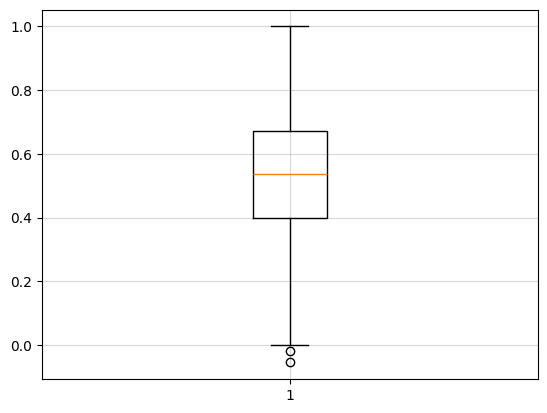

In [ ]:
plt.boxplot(df['Возраст'])
plt.grid(alpha=0.5)

# тк размах усов достаточно большой, а медиана не смещена - выберем медиану в качестве порога бинаризации

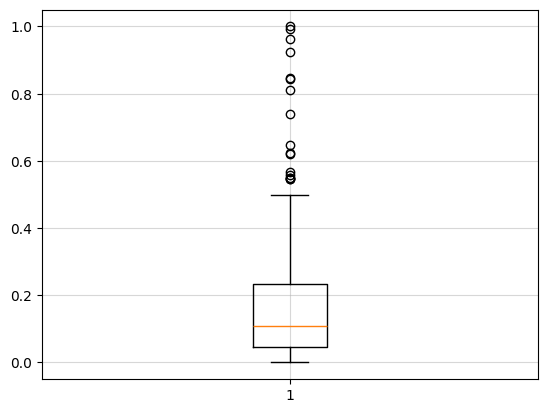

In [ ]:
plt.boxplot(df['Объем очагов'])
plt.grid(alpha=0.5)

# видим много выбросов, можем задать Volume Binary как "является выбросом / не является" (лежин ли в пределах wiskers)

In [ ]:
df['Age (Binary)'] = 0
df['Volume (Binary)'] = 0
df['Previous operations (Binary)'] = 0

# Бинарный возраст
mean_age = df['Возраст'].mean()
win_age = df[df['Возраст'] >= mean_age].index

df.loc[win_age, 'Age (Binary)'] = 1

# Бинарный объем очагов
IQR_vol = np.quantile(df['Объем очагов'], 0.75) - np.quantile(df['Объем очагов'], 0.25)
sel_vol_min = np.quantile(df['Объем очагов'], 0.25) - 1.5 * IQR_vol
sel_vol_max = np.quantile(df['Объем очагов'], 0.75) + 1.5 * IQR_vol
win_vol = df[(df['Объем очагов'] >= sel_vol_min) & (df['Объем очагов'] <= sel_vol_max)].index

df.loc[win_vol, 'Volume (Binary)'] = 1

# Бинарное наличие / отсутствие операций
win_prev = df[(df['ОВГМ'] == 1) | (df['Операция'] == 1)].index

df.loc[win_prev, 'Previous operations (Binary)'] = 1

df

,Прогрессия,Число очагов,Объем очагов,Число РХ процедур,Индекс Карновского,ОВГМ,Операция,Возраст,Время метастазирования,Время реагирования,...,НМРЛ,РМЖ,РП,Таргетная терапия,Химиотерапия,Без лечения,Мужчина,Age (Binary),Volume (Binary),Previous operations (Binary)
0,1,0.095238,0.008543,0.0,0.666667,0,0,0.490909,0.076249,0.165963,...,0,0,0,0,1,0,1,0,1,0
1,1,0.095238,0.101619,0.0,0.666667,0,0,0.690909,0.034228,-0.004219,...,0,0,1,0,0,0,1,1,1,0
2,0,0.476190,0.178732,0.0,0.666667,0,0,0.454545,0.203423,0.018284,...,0,0,0,0,1,0,0,0,1,0
3,1,0.285714,0.062950,0.2,0.666667,0,0,0.472727,0.068179,0.030942,...,0,1,0,1,0,0,0,0,1,0
4,1,0.476190,0.127023,0.8,0.666667,0,0,0.472727,0.012801,0.014065,...,0,0,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,0,0.000000,0.268885,0.0,0.500000,0,0,0.618182,0.093363,0.032349,...,0,0,0,0,1,0,1,1,1,0
544,1,0.857143,0.044739,0.4,0.666667,1,0,0.181818,0.115208,-0.015471,...,0,0,0,1,0,0,0,0,1,1
545,0,0.523810,0.214478,0.0,0.500000,0,0,0.072727,0.016836,0.028129,...,0,0,0,0,0,0,1,0,1,0
546,0,0.142857,0.054406,0.0,0.500000,0,0,0.545455,0.080840,0.042194,...,0,0,1,1,0,0,0,1,1,0


Добавляем анализ таблиц сопряжённости для новых признаков

In [ ]:
# Возраст (Бинарный)

analyze_2x2_table(df, 'Age (Binary)', target)

Таблица сопряжённости:


Прогрессия,0,1,All
Age (Binary),,,
0,70,178,248
1,109,191,300
All,179,369,548


Риски:
  R(Age (Binary)=0) = 178/248 = 0.718 (71.8%)
  R(Age (Binary)=1) = 191/300 = 0.637 (63.7%)

Шансы:
  O(Age (Binary)=0) = 178/70 = 2.54
  O(Age (Binary)=1) = 191/109 = 1.75

Меры сравнения:
  RD (разница рисков) = 0.081
  RR (относительный риск) = 1.13
  OR (отношение шансов) = 1.45



{'feature': 'Age (Binary)',
 'R1': np.float64(0.717741935483871),
 'R2': np.float64(0.6366666666666667),
 'O1': np.float64(2.5428571428571427),
 'O2': np.float64(1.7522935779816513),
 'RD': np.float64(0.08107526881720428),
 'RR': np.float64(1.1273433541631481),
 'OR': np.float64(1.451159311892296)}

In [ ]:
# Обьем очага (Бинарный)

analyze_2x2_table(df, 'Volume (Binary)', target)

Таблица сопряжённости:


Прогрессия,0,1,All
Volume (Binary),,,
0,7,10,17
1,172,359,531
All,179,369,548


Риски:
  R(Volume (Binary)=0) = 10/17 = 0.588 (58.8%)
  R(Volume (Binary)=1) = 359/531 = 0.676 (67.6%)

Шансы:
  O(Volume (Binary)=0) = 10/7 = 1.43
  O(Volume (Binary)=1) = 359/172 = 2.09

Меры сравнения:
  RD (разница рисков) = -0.088
  RR (относительный риск) = 0.87
  OR (отношение шансов) = 0.68



{'feature': 'Volume (Binary)',
 'R1': np.float64(0.5882352941176471),
 'R2': np.float64(0.6760828625235404),
 'O1': np.float64(1.4285714285714286),
 'O2': np.float64(2.0872093023255816),
 'RD': np.float64(-0.08784756840589336),
 'RR': np.float64(0.8700639029985254),
 'OR': np.float64(0.6844409072821329)}

In [ ]:
# Наличие / отсутствие предыдущих операций

analyze_2x2_table(df, 'Previous operations (Binary)', target)

Таблица сопряжённости:


Прогрессия,0,1,All
Previous operations (Binary),,,
0,137,245,382
1,42,124,166
All,179,369,548


Риски:
  R(Previous operations (Binary)=0) = 245/382 = 0.641 (64.1%)
  R(Previous operations (Binary)=1) = 124/166 = 0.747 (74.7%)

Шансы:
  O(Previous operations (Binary)=0) = 245/137 = 1.79
  O(Previous operations (Binary)=1) = 124/42 = 2.95

Меры сравнения:
  RD (разница рисков) = -0.106
  RR (относительный риск) = 0.86
  OR (отношение шансов) = 0.61



{'feature': 'Previous operations (Binary)',
 'R1': np.float64(0.6413612565445026),
 'R2': np.float64(0.7469879518072289),
 'O1': np.float64(1.7883211678832116),
 'O2': np.float64(2.9523809523809526),
 'RD': np.float64(-0.10562669526272628),
 'RR': np.float64(0.8585965208579632),
 'OR': np.float64(0.6057216858959265)}